In [3]:
import os

import pandas as pd
import numpy as np

from dotenv import load_dotenv

from sqlalchemy import create_engine

import plotly.express as px
import plotly.graph_objects as go

In [4]:
load_dotenv()

DATABASE_URL = os.getenv("DATABASE_URL")

engine = create_engine(DATABASE_URL)

In [5]:
channels_df = pd.read_sql(
    "SELECT * FROM channels",
    engine
)

videos_df = pd.read_sql(
    "SELECT * FROM videos",
    engine
)

comments_df = pd.read_sql(
    "SELECT * FROM comments",
    engine
)

In [6]:
print("Channels :", channels_df.shape)

print("Videos :", videos_df.shape)

print("Comments :", comments_df.shape)

Channels : (1, 8)
Videos : (50, 13)
Comments : (4200, 21)


In [7]:
total_subscribers = channels_df["subscriber_count"].sum()

total_views = channels_df["total_views"].sum()

total_videos = len(videos_df)

total_comments = len(comments_df)

positive_comments = (
    comments_df["sentiment"] == "Positive"
).sum()

neutral_comments = (
    comments_df["sentiment"] == "Neutral"
).sum()

negative_comments = (
    comments_df["sentiment"] == "Negative"
).sum()

spam_comments = (
    comments_df["is_spam"] == True
).sum()

abusive_comments = (
    comments_df["contains_abusive_language"] == True
).sum()

In [8]:
kpi_df = pd.DataFrame({

    "Metric":[

        "Subscribers",
        "Views",
        "Videos",
        "Comments",
        "Positive",
        "Neutral",
        "Negative",
        "Spam",
        "Abusive"

    ],

    "Value":[

        total_subscribers,
        total_views,
        total_videos,
        total_comments,
        positive_comments,
        neutral_comments,
        negative_comments,
        spam_comments,
        abusive_comments

    ]

})

kpi_df

,Metric,Value
0,Subscribers,7700000
1,Views,1284141607
2,Videos,50
3,Comments,4200
4,Positive,1976
5,Neutral,2013
6,Negative,211
7,Spam,31
8,Abusive,288


In [9]:
fig = px.bar(

    kpi_df,

    x="Metric",

    y="Value",

    title="InfluenceIQ KPI Dashboard",

    text="Value"

)

fig.show()

In [10]:
fig = go.Figure()

fig.add_trace(

    go.Indicator(

        mode="number",

        value=total_views,

        title={"text":"Total Views"}

    )

)

fig.show()

In [11]:
fig = go.Figure()

fig.add_trace(

    go.Indicator(

        mode="number",

        value=total_subscribers,

        title={"text":"Subscribers"}

    )

)

fig.show()

In [12]:
fig = go.Figure()

fig.add_trace(

    go.Indicator(

        mode="number",

        value=total_videos,

        title={"text":"Videos"}

    )

)

fig.show()

In [13]:
fig = go.Figure()

fig.add_trace(

    go.Indicator(

        mode="number",

        value=total_comments,

        title={"text":"Comments"}

    )

)

fig.show()

In [14]:
average_views = videos_df["view_count"].mean()

average_views

np.float64(272673.24)

In [15]:
average_likes = videos_df["like_count"].mean()

average_likes

np.float64(9396.06)

In [16]:
average_comments = videos_df["comment_count"].mean()

average_comments

np.float64(425.64)

In [17]:
summary = pd.DataFrame({

    "Metric":[

        "Average Views",

        "Average Likes",

        "Average Comments"

    ],

    "Value":[

        average_views,

        average_likes,

        average_comments

    ]

})

summary

,Metric,Value
0,Average Views,272673.24
1,Average Likes,9396.06
2,Average Comments,425.64


In [18]:
fig = px.bar(

    summary,

    x="Metric",

    y="Value",

    text="Value",

    title="Average Engagement Metrics"

)

fig.show()

In [19]:
top_views = videos_df.nlargest(
    10,
    "view_count"
)

fig = px.bar(

    top_views,

    x="view_count",

    y="title",

    orientation="h",

    title="Top 10 Most Viewed Videos",

    text="view_count"

)

fig.update_layout(

    yaxis=dict(autorange="reversed")

)

fig.show()

In [20]:
top_likes = videos_df.nlargest(
    10,
    "like_count"
)

fig = px.bar(

    top_likes,

    x="like_count",

    y="title",

    orientation="h",

    title="Top 10 Most Liked Videos",

    text="like_count"

)

fig.update_layout(

    yaxis=dict(autorange="reversed")

)

fig.show()

In [21]:
top_comments = videos_df.nlargest(
    10,
    "comment_count"
)

fig = px.bar(

    top_comments,

    x="comment_count",

    y="title",

    orientation="h",

    title="Top 10 Most Commented Videos",

    text="comment_count"

)

fig.update_layout(

    yaxis=dict(autorange="reversed")

)

fig.show()

In [22]:
videos_df["engagement_rate"] = (

    videos_df["like_count"]

    +

    videos_df["comment_count"]

) / videos_df["view_count"] * 100

In [23]:
videos_df[
    [

        "title",

        "engagement_rate"

    ]

].head()

,title,engagement_rate
0,When is the Best Time to start Coding for Plac...,6.629486
1,FLIPKART OFF-Campus Interview Experience | Com...,3.216668
2,Complete Interview Experiences for OFF-Campus ...,3.414929
3,Generative AI vs Agentic AI vs AI Agents,3.917543
4,OFF Campus : Flipkart selection process for So...,3.379273


In [24]:
top_engagement = videos_df.nlargest(

    10,

    "engagement_rate"

)

fig = px.bar(

    top_engagement,

    x="engagement_rate",

    y="title",

    orientation="h",

    text="engagement_rate",

    title="Top 10 Engagement Rate"

)

fig.update_layout(

    yaxis=dict(autorange="reversed")

)

fig.show()

In [25]:
fig = px.scatter(

    videos_df,

    x="view_count",

    y="like_count",

    hover_name="title",

    title="Views vs Likes"

)

fig.show()

In [26]:
fig = px.scatter(

    videos_df,

    x="view_count",

    y="comment_count",

    hover_name="title",

    title="Views vs Comments"

)

fig.show()

In [27]:
fig = px.scatter(

    videos_df,

    x="like_count",

    y="comment_count",

    hover_name="title",

    title="Likes vs Comments"

)

fig.show()

In [28]:
fig = px.scatter(

    videos_df,

    x="view_count",

    y="like_count",

    size="comment_count",

    hover_name="title",

    title="Bubble Chart : Views, Likes & Comments"

)

fig.show()

In [29]:
fig = px.histogram(

    videos_df,

    x="duration",

    title="Video Duration Distribution"

)

fig.show()

In [30]:
fig = px.histogram(

    videos_df,

    x="view_count",

    nbins=20,

    title="View Count Distribution"

)

fig.show()

In [31]:
fig = px.histogram(

    videos_df,

    x="like_count",

    nbins=20,

    title="Like Distribution"

)

fig.show()

In [32]:
fig = px.histogram(

    videos_df,

    x="comment_count",

    nbins=20,

    title="Comment Distribution"

)

fig.show()

In [33]:
top_engagement[
    [

        "title",

        "engagement_rate",

        "view_count",

        "like_count",

        "comment_count"

    ]

]

,title,engagement_rate,view_count,like_count,comment_count
0,When is the Best Time to start Coding for Plac...,6.629486,69749,4520,104
15,"WAKE UP CALL for 1st, 2nd year students - Know...",5.486483,269444,13940,843
10,5 Things you should know before Engineering | ...,5.246948,208445,10398,539
27,17 LPA+ @ HPE : Best Strategy for Placement🚀,4.462910,433596,19216,135
14,How to get Placement in 6 months ? Study Plan ...,4.387601,195665,8127,458
18,The Complete Data Science RoadMap | from Basic...,4.321307,469395,19351,933
38,Top Skills that every Software Engineer MUST l...,4.251208,291917,11726,684
36,How to Start Coding ? Learn Programming for Be...,4.203831,965976,38775,1833
24,Data Analyst vs Data Scientist vs AI Engineer ...,4.145722,281495,11078,592
25,The most important TIME in College. Importance...,4.137669,397156,16204,229


In [34]:
print("========== VIDEO PERFORMANCE ==========\n")

print(

f"Average Views : {videos_df['view_count'].mean():,.0f}"

)

print(

f"Average Likes : {videos_df['like_count'].mean():,.0f}"

)

print(

f"Average Comments : {videos_df['comment_count'].mean():,.0f}"

)

print(

f"Highest Engagement : {videos_df['engagement_rate'].max():.2f}%"

)

========== VIDEO PERFORMANCE ==========

Average Views : 272,673
Average Likes : 9,396
Average Comments : 426
Highest Engagement : 6.63%


In [35]:
# # 📊 Part 2 Summary

# The following analyses were completed:

# - Top Viewed Videos
# - Top Liked Videos
# - Top Commented Videos
# - Engagement Rate
# - Views vs Likes
# - Views vs Comments
# - Likes vs Comments
# - Bubble Chart
# - Video Distribution

# These visualizations help identify the best-performing content and understand audience engagement patterns.

In [36]:
sentiment_df = (
    comments_df["sentiment"]
    .value_counts()
    .reset_index()
)

sentiment_df.columns = [
    "Sentiment",
    "Count"
]

sentiment_df

,Sentiment,Count
0,Neutral,2013
1,Positive,1976
2,Negative,211


In [37]:
fig = px.pie(

    sentiment_df,

    names="Sentiment",

    values="Count",

    title="Sentiment Distribution"

)

fig.show()

In [38]:
fig = px.bar(

    sentiment_df,

    x="Sentiment",

    y="Count",

    color="Sentiment",

    text="Count",

    title="Sentiment Analysis"

)

fig.show()

In [39]:
spam_df = (
    comments_df["is_spam"]
    .value_counts()
    .reset_index()
)

spam_df.columns = [

    "Spam",

    "Count"

]

spam_df

,Spam,Count
0,False,4169
1,True,31


In [40]:
spam_df["Spam"] = spam_df["Spam"].replace({

    True:"Spam",

    False:"Normal"

})

fig = px.pie(

    spam_df,

    names="Spam",

    values="Count",

    title="Spam Detection"

)

fig.show()

In [41]:
abusive_df = (
    comments_df["contains_abusive_language"]
    .value_counts()
    .reset_index()
)

abusive_df.columns = [

    "Abusive",

    "Count"

]

In [42]:
abusive_df["Abusive"] = abusive_df["Abusive"].replace({

    True:"Abusive",

    False:"Normal"

})

fig = px.pie(

    abusive_df,

    names="Abusive",

    values="Count",

    title="Abusive Language Detection"

)

fig.show()

In [43]:
length_df = (
    comments_df["comment_length"]
    .value_counts()
    .reset_index()
)

length_df.columns = [

    "Length",

    "Comments"

]

length_df

,Length,Comments
0,Medium,2394
1,Long,914
2,Short,892


In [44]:
fig = px.bar(

    length_df,

    x="Length",

    y="Comments",

    text="Comments",

    color="Length",

    title="Comment Length Distribution"

)

fig.show()

In [45]:
fig = px.histogram(

    comments_df,

    x="word_count",

    nbins=30,

    title="Word Count Distribution"

)

fig.show()

In [46]:
fig = px.histogram(

    comments_df,

    x="character_count",

    nbins=30,

    title="Character Count Distribution"

)

fig.show()

In [47]:
question_df = (
    comments_df["contains_question"]
    .value_counts()
    .reset_index()
)

question_df.columns = [

    "Question",

    "Count"

]

question_df

,Question,Count
0,False,3468
1,True,732


In [48]:
question_df["Question"] = question_df["Question"].replace({

    True:"Question",

    False:"Normal"

})

fig = px.pie(

    question_df,

    names="Question",

    values="Count",

    title="Question Based Comments"

)

fig.show()

In [49]:
exclamation_df = (
    comments_df["contains_exclamation"]
    .value_counts()
    .reset_index()
)

exclamation_df.columns = [

    "Exclamation",

    "Count"

]

In [50]:
exclamation_df["Exclamation"] = exclamation_df["Exclamation"].replace({

    True:"Yes",

    False:"No"

})

fig = px.pie(

    exclamation_df,

    names="Exclamation",

    values="Count",

    title="Exclamation Comments"

)

fig.show()

In [51]:
summary = pd.DataFrame({

    "Metric":[

        "Positive",

        "Neutral",

        "Negative",

        "Spam",

        "Abusive"

    ],

    "Count":[

        positive_comments,

        neutral_comments,

        negative_comments,

        spam_comments,

        abusive_comments

    ]

})

summary

,Metric,Count
0,Positive,1976
1,Neutral,2013
2,Negative,211
3,Spam,31
4,Abusive,288


In [52]:
fig = px.bar(

    summary,

    x="Metric",

    y="Count",

    color="Metric",

    text="Count",

    title="NLP Summary Dashboard"

)

fig.show()

In [53]:
comments_df.groupby(

    "sentiment"

)[

    "word_count"

].mean()

sentiment
Negative    23.175355
Neutral      9.015897
Positive    19.956478
Name: word_count, dtype: float64

In [54]:
comments_df.groupby(

    "sentiment"

)[

    "character_count"

].mean()

sentiment
Negative    122.881517
Neutral      48.635370
Positive    107.373482
Name: character_count, dtype: float64

In [55]:
print("========== NLP INSIGHTS ==========\n")

print(

f"Positive : {positive_comments}"

)

print(

f"Neutral : {neutral_comments}"

)

print(

f"Negative : {negative_comments}"

)

print()

print(

f"Spam : {spam_comments}"

)

print(

f"Abusive : {abusive_comments}"

)

print()

print(

f"Average Words : {comments_df['word_count'].mean():.2f}"

)

print(

f"Average Characters : {comments_df['character_count'].mean():.2f}"

)

========== NLP INSIGHTS ==========

Positive : 1976
Neutral : 2013
Negative : 211

Spam : 31
Abusive : 288

Average Words : 14.87
Average Characters : 80.00


In [61]:
from wordcloud import WordCloud

from collections import Counter

import matplotlib.pyplot as plt

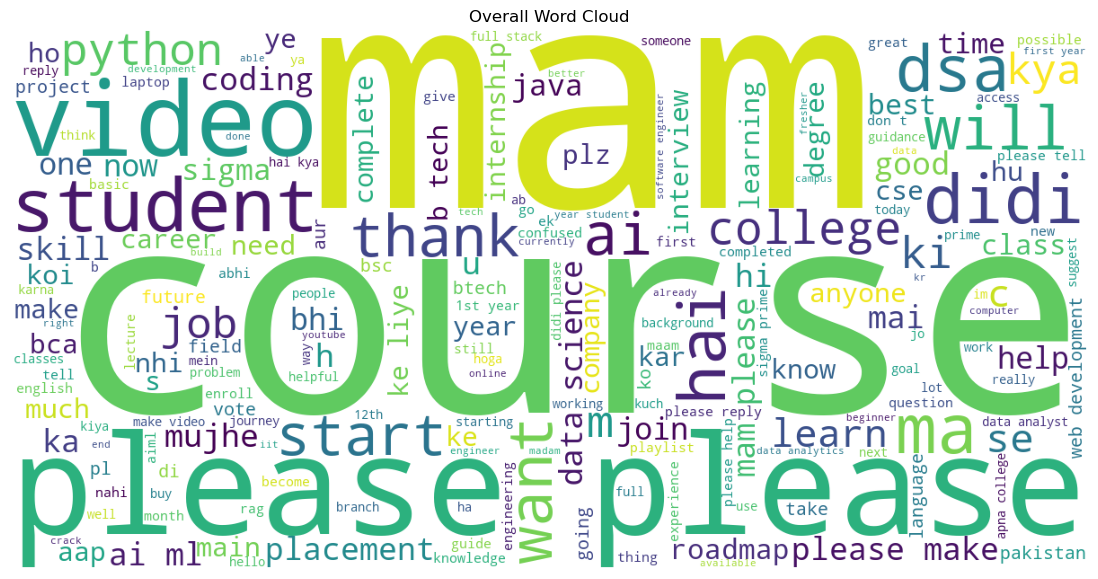

In [62]:
text = " ".join(

    comments_df["clean_comment"]

    .fillna("")

    .astype(str)

)

wordcloud = WordCloud(

    width=1200,

    height=600,

    background_color="white"

).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Overall Word Cloud")

plt.show()

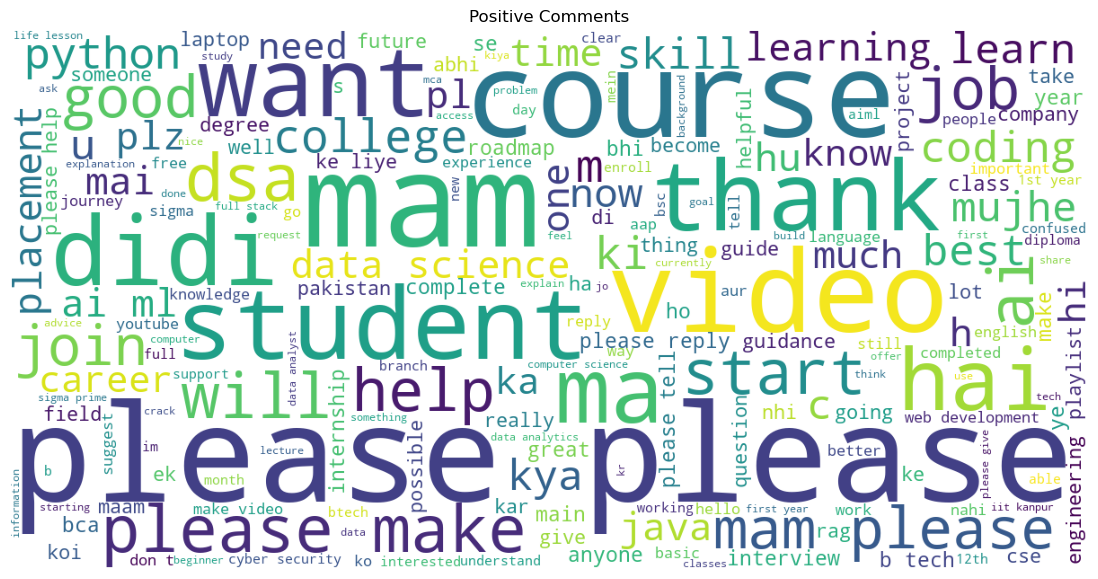

In [63]:
positive_text = " ".join(

    comments_df

    [

        comments_df["sentiment"]=="Positive"

    ]

    ["clean_comment"]

    .fillna("")

)

wordcloud = WordCloud(

    width=1200,

    height=600,

    background_color="white"

).generate(positive_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Comments")

plt.show()

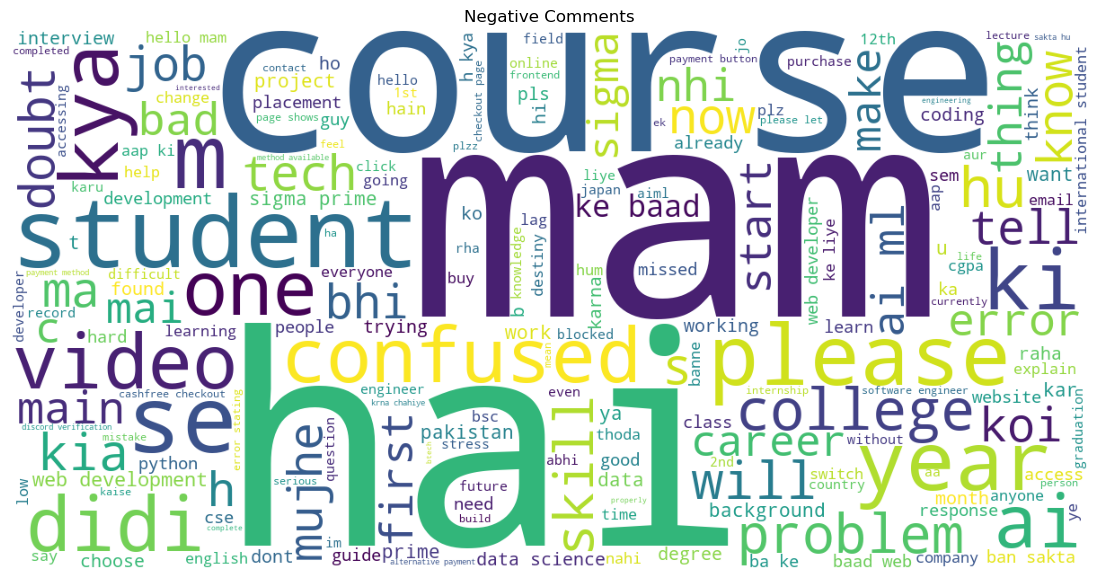

In [64]:
negative_text = " ".join(

    comments_df

    [

        comments_df["sentiment"]=="Negative"

    ]

    ["clean_comment"]

    .fillna("")

)

wordcloud = WordCloud(

    width=1200,

    height=600,

    background_color="white"

).generate(negative_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Comments")

plt.show()

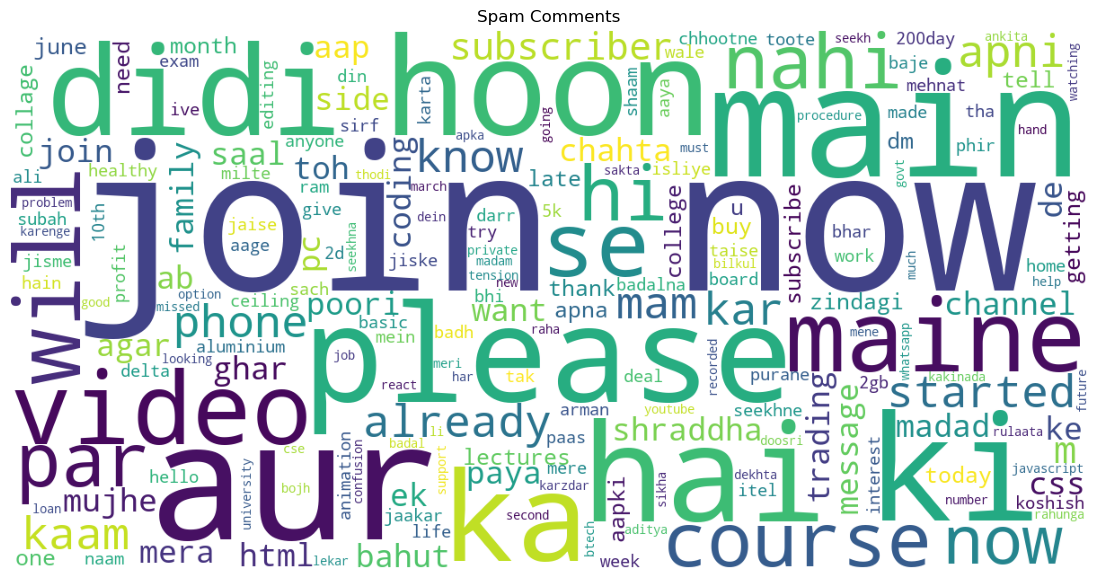

In [65]:
spam_text = " ".join(

    comments_df

    [

        comments_df["is_spam"]

    ]

    ["clean_comment"]

    .fillna("")

)

if spam_text.strip():

    wordcloud = WordCloud(

        width=1200,

        height=600,

        background_color="white"

    ).generate(spam_text)

    plt.figure(figsize=(15,7))

    plt.imshow(wordcloud)

    plt.axis("off")

    plt.title("Spam Comments")

    plt.show()

else:

    print("No Spam Comments Available")

In [66]:
words = " ".join(

    comments_df["clean_comment"]

    .fillna("")

).split()

counter = Counter(words)

top_words = pd.DataFrame(

    counter.most_common(20),

    columns=[

        "Word",

        "Frequency"

    ]

)

top_words

,Word,Frequency
0,i,1907
1,please,1288
2,to,1182
3,and,913
4,in,907
5,a,875
6,mam,841
7,for,808
8,am,724
9,me,707


In [67]:
fig = px.bar(

    top_words,

    x="Frequency",

    y="Word",

    orientation="h",

    text="Frequency",

    title="Top 20 Most Frequent Words"

)

fig.update_layout(

    yaxis=dict(

        autorange="reversed"

    )

)

fig.show()

In [68]:
engagement = pd.DataFrame({

    "Metric":[

        "Average Views",

        "Average Likes",

        "Average Comments",

        "Average Word Count"

    ],

    "Value":[

        videos_df["view_count"].mean(),

        videos_df["like_count"].mean(),

        videos_df["comment_count"].mean(),

        comments_df["word_count"].mean()

    ]

})

engagement

,Metric,Value
0,Average Views,272673.240000
1,Average Likes,9396.060000
2,Average Comments,425.640000
3,Average Word Count,14.874524


In [69]:
print("="*60)

print("BUSINESS INSIGHTS")

print("="*60)

print()

print(f"Total Videos               : {len(videos_df)}")

print(f"Total Comments             : {len(comments_df)}")

print(f"Average Views              : {videos_df['view_count'].mean():,.0f}")

print(f"Average Likes              : {videos_df['like_count'].mean():,.0f}")

print(f"Average Comments           : {videos_df['comment_count'].mean():,.0f}")

print()

print(f"Positive Comments          : {positive_comments}")

print(f"Neutral Comments           : {neutral_comments}")

print(f"Negative Comments          : {negative_comments}")

print()

print(f"Spam Comments              : {spam_comments}")

print(f"Abusive Comments           : {abusive_comments}")

print()

print(f"Average Word Count         : {comments_df['word_count'].mean():.2f}")

print(f"Average Character Count    : {comments_df['character_count'].mean():.2f}")

print()

print(f"Highest Viewed Video")

print(

videos_df.loc[

videos_df["view_count"].idxmax(),

"title"

]

)

print()

print(f"Highest Liked Video")

print(

videos_df.loc[

videos_df["like_count"].idxmax(),

"title"

]

)

BUSINESS INSIGHTS

Total Videos               : 50
Total Comments             : 4200
Average Views              : 272,673
Average Likes              : 9,396
Average Comments           : 426

Positive Comments          : 1976
Neutral Comments           : 2013
Negative Comments          : 211

Spam Comments              : 31
Abusive Comments           : 288

Average Word Count         : 14.87
Average Character Count    : 80.00

Highest Viewed Video
What's the BEST Tech Career in 2026 ? | High Paying, Growth & Stability

Highest Liked Video
How to Start Coding ? Learn Programming for Beginners | 2026


In [70]:
# # 📊 Executive Summary

# This project successfully built an end-to-end YouTube Analytics and NLP Pipeline.

# ### Dataset

# - YouTube Channels
# - Videos
# - Comments

# ### Pipeline

# - Data Collection
# - PostgreSQL Storage
# - ETL
# - Cleaning
# - Spam Detection
# - Sentiment Analysis
# - Abusive Language Detection
# - Feature Engineering

# ### Analysis

# - Exploratory Data Analysis
# - Interactive Plotly Dashboard
# - WordCloud
# - Business Insights

# ### Outcome

# The project provides valuable insights into audience engagement, comment quality, sentiment distribution and overall content performance.